In [46]:
import numpy as np
from matplotlib import pyplot as plt

# The Game of Life

According to [Wikipedia](https://en.wikipedia.org/wiki/Conway%27s_Game_of_Life):

> The Game of Life is a cellular automaton devised by the mathematician John Horton Conway in 1970. In this "game" the evolution of the board is determined by its initial state. One interacts with the Game of Life by creating an initial configuration and observing how it evolves.  The game is known to be [Turing complete](https://en.wikipedia.org/wiki/Turing_completeness).


Each cell in the the grid is in one of two possible states, alive or dead, and evolves according to the rules described below.  Here's an example of a board configuration and its evolution:

<img style="float: center;" src="https://upload.wikimedia.org/wikipedia/commons/e/e5/Gospers_glider_gun.gif" width="250">

### Rules of the game:

Every cell in the board interacts with its eight neighbours, which are the cells that are horizontally, vertically, or diagonally adjacent. At each step in time, the following rules are applied:

1. Any live cell with fewer than two live neighbours dies, simulating the effects of underpopulation.
2. Any live cell with two or three live neighbours lives on to the next generation.
3. Any live cell with more than three live neighbours dies, simulating the effects of overpopulation.
4. Any dead cell with exactly three live neighbours becomes a live cell, simulating reproduction.

At each step these rules are applied simultaneously to all cells, leading to the next state.

### The Game of Life in NumPy

Let's start by creating an initial state of the board.  To make things easy for ourselves, the board will have a border of all zeros.   Therefore the following 6x6 array represents a 4x4 board:

In [47]:
Z = np.array([[0,0,0,0,0,0],
              [0,0,0,1,0,0],
              [0,1,0,1,0,0],
              [0,0,1,1,0,0],
              [0,0,0,0,0,0],
              [0,0,0,0,0,0]])

print ('Initial state:')
print (Z[1:-1,1:-1])

Initial state:
[[0 0 1 0]
 [1 0 1 0]
 [0 1 1 0]
 [0 0 0 0]]


Next, we'll create a function that runs an iteration of the game according to the rules described above:

In [48]:
# adapted from https://dana.loria.fr/doc/game-of-life.html

def iterate(Z):
    # find the number of neighbours that each square has
    N = np.zeros(Z.shape)
    # need to take into account eight neighbors of each cell
    N[1:, 1:] += Z[:-1, :-1]
    N[1:, :-1] += Z[:-1, 1:]
    N[:-1, 1:] += Z[1:, :-1]
    N[:-1, :-1] += Z[1:, 1:]
    N[:-1, :] += Z[1:, :]
    N[1:, :] += Z[:-1, :]
    N[:, :-1] += Z[:, 1:]
    N[:, 1:] += Z[:, :-1]
    # a live cell lives on if it has two or three neighbors:
    rule123 = ((Z == 1) & (N < 4) & (N > 1)) 
    # a dead cell becomes alive if it has exactly three live neighbors:
    rule4 = ((Z == 0) & (N == 3))
    return (rule123 | rule4).astype(int)


Note the use of the [astype](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.astype.html) method, which casts an array into a desired type.  By default a new copy of the array is created.
Also note that the neighbors can be computed with the help of [np.roll](https://numpy.org/doc/stable/reference/generated/numpy.roll.html).

Our initial state is a [glider](https://en.wikipedia.org/wiki/Glider_(Conway's_Life)) which moves across the board, its overall shape unchanged:

In [49]:
print ('Initial state:')
print (Z[1:-1,1:-1])
for i in range(4):
    Z = iterate(Z)
print ('Final state:')
print (Z[1:-1,1:-1])

Initial state:
[[0 0 1 0]
 [1 0 1 0]
 [0 1 1 0]
 [0 0 0 0]]
Final state:
[[0 0 0 0]
 [0 0 0 1]
 [0 1 0 1]
 [0 0 1 1]]


In [50]:
glider = np.array([[0,0,0,0,0,0],
                   [0,0,0,1,0,0],
                   [0,1,0,1,0,0],
                   [0,0,1,1,0,0],
                   [0,0,0,0,0,0],
                   [0,0,0,0,0,0]])

Z = np.zeros(shape=(30,30))
Z[0:6,0:6]=glider

Z = np.random.choice([0,1], size=(30,30), p=[0.85, 0.15])

In [51]:
def animate(n) :
    global Z
    Z = iterate(Z)
    mat.set_data(Z[1:-1,1:-1])
    #return [mat]

In [52]:
%%capture
fig, ax = plt.subplots()
ax.axis('off')
mat = ax.matshow(Z[1:-1,1:-1], cmap = 'Greys')
from matplotlib.animation import FuncAnimation,PillowWriter  
anim = FuncAnimation(fig, animate, frames = 50, 
                     interval = 200, repeat=True)
writer = PillowWriter() 
anim.save('animation.gif', writer=writer)

Now that we created the animation we can either display it in a markdown cell or in a code cell:

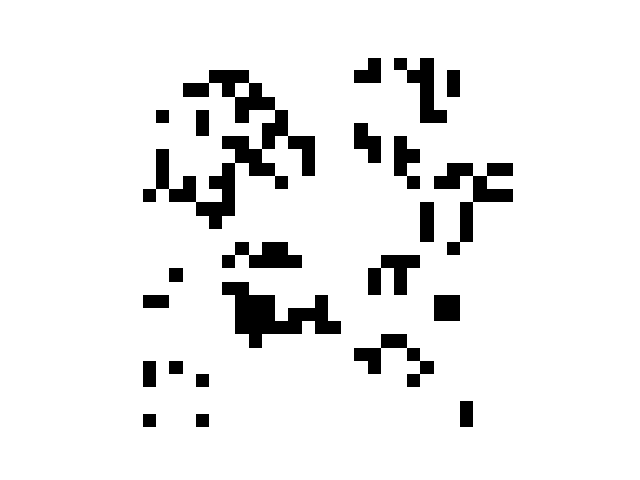

In [53]:
from IPython.display import Image
Image('animation.gif', width=300)